# Segmentation images using U-net

In [ ]:

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision import models
from sklearn.model_selection import train_test_split
from PIL import Image
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Define the architecture of ResNet50

In [4]:
class CustomResNet50(nn.Module):
    def __init__(self):
        super(CustomResNet50, self).__init__()
        self.backbone = models.resnet50(pretrained = True)
        self.backbone.fc = nn.Identity()
        self.rotation_head = nn.Linear(2048, 4)

        self.rotation_head = nn.Sequential(
            nn.Linear(2048, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
        
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        rotate_pred = self.rotation_head(features)
        return rotate_pred

In [5]:
model = CustomResNet50()
model = model.to(device)

model.load_state_dict(torch.load("binary_model_4.pth"))

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

## Remove the last part of the architecture

In [6]:
class ResNetEncoder(nn.Module):
    def __init__(self, model):
        super(ResNetEncoder, self).__init__()

        self.encoder = nn.Sequential(*list(model.backbone.children())[:-2])

    def forward(self, x):
        features = self.encoder(x)
        return features

## Add a decoder

In [7]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(1024, 512, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(512, 256, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            nn.Conv2d(64, 1, kernel_size=1)  # final reconstruction (RGB)
        )

    def forward(self, x):
        return self.decoder(x)


## Combine both

In [8]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        self.encoder = ResNetEncoder(model)
        self.encoder = self.encoder.to(device)
        self.decoder = Decoder()
        self.decoder = self.decoder.to(device)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [9]:
uNetModel = AutoEncoder()
uNetModel = uNetModel.to(device)
x = torch.randn(1, 3, 224, 224).to(device)
y = uNetModel(x)
print(y.shape)


torch.Size([1, 1, 224, 224])


In [10]:
uNetModel.load_state_dict(torch.load("uNetModel_best.pth"))

<All keys matched successfully>

## Generate the dataset

In [12]:
from torch.utils.data import Dataset
from PIL import Image
import os, random
import torchvision.transforms.functional as F


class BrainTumourDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_transform=None, mask_transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_transform = img_transform
        self.mask_transform = mask_transform

        self.image_names = []
        for img_name in os.listdir(img_dir):
            base_name = os.path.splitext(img_name)[0]
            mask_name = base_name + ".png"
            mask_path = os.path.join(mask_dir, mask_name)
            if os.path.exists(mask_path):
                self.image_names.append(img_name)

        print(f"✅ Total usable image-mask pairs: {len(self.image_names)}")

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        base_name = os.path.splitext(img_name)[0]
        mask_name = base_name + ".png"

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # 🧠 Apply joint transforms (only on training set)
        if "train" in self.img_dir:
            image, mask = joint_transform(image, mask)

        # 🧩 Apply individual transforms
        if self.img_transform:
            image = self.img_transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask


## Create transforms

In [13]:
from torchvision import transforms

# 🏋️ TRAIN TRANSFORMS (with augmentations)
train_transform_img = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_transform_mask = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

# 🧪 TEST TRANSFORMS (no random stuff)
test_transform_img = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform_mask = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


In [24]:
from torchvision import transforms
import torchvision.transforms.functional as F
import random
import torch

class JointTransform:
    def __init__(self):
        self.hflip_prob = 0.5
        self.vflip_prob = 0.5
        self.rotation_deg = 15

    def __call__(self, img, mask):
        if random.random() < self.hflip_prob:
            img = F.hflip(img)
            mask = F.hflip(mask)

        if random.random() < self.vflip_prob:
            img = F.vflip(img)
            mask = F.vflip(mask)

        angle = random.uniform(-self.rotation_deg, self.rotation_deg)
        img = F.rotate(img, angle)
        mask = F.rotate(mask, angle)

        return img, mask


# Instantiate joint transform
joint_transform = JointTransform()

# 🏋️ TRAIN TRANSFORMS (buffed but keeping your resize)
train_transform_img = transforms.Compose([
    transforms.Resize((128, 128)),  # don't touch this
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.03),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_transform_mask = transforms.Compose([
    transforms.Resize((128, 128)),  # untouched
    transforms.ToTensor(),
])

# 🧪 TEST TRANSFORMS (stay clean)
test_transform_img = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform_mask = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])


## Define path and dataset

In [25]:
train_dataset = BrainTumourDataset(
    img_dir="segmentation-dataset/segmentation_task/train/images",
    mask_dir="segmentation-dataset/segmentation_task/train/masks",
    img_transform=train_transform_img,
    mask_transform=train_transform_mask
)

test_dataset = BrainTumourDataset(
    img_dir="segmentation-dataset/segmentation_task/test/images",
    mask_dir="segmentation-dataset/segmentation_task/test/masks",
    img_transform=test_transform_img,
    mask_transform=test_transform_mask
)


✅ Total usable image-mask pairs: 3933
✅ Total usable image-mask pairs: 860


## View the dataset

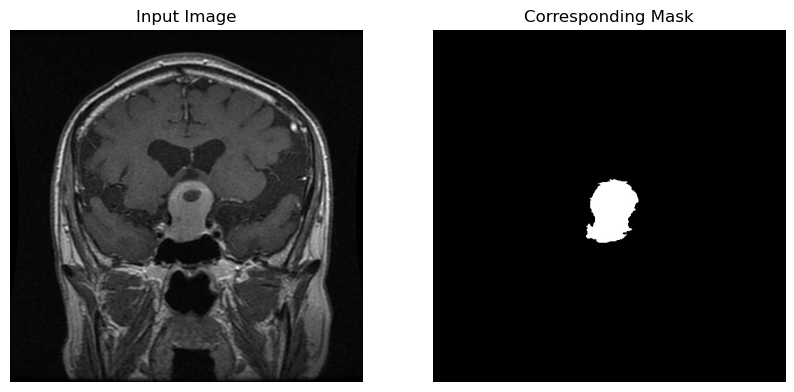

In [26]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Paths
image_dir = "segmentation-dataset/segmentation_task/train/images"
mask_dir = "segmentation-dataset/segmentation_task/train/masks"

# List sorted files to keep consistent ordering
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

# Pick random index
idx = random.randint(0, len(image_files) - 1)

# Load image & mask using same index
img_path = os.path.join(image_dir, image_files[idx])
mask_path = os.path.join(mask_dir, mask_files[idx])

img = Image.open(img_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

# Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Corresponding Mask")
plt.axis("off")

plt.show()


## Define loss_fn & optimizer

In [27]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

bce_loss = nn.BCEWithLogitsLoss()

# Dice Loss
# def dice_loss(pred, target, smooth=1e-6):
#     pred = torch.sigmoid(pred)
#     intersection = (pred * target).sum()
#     return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# def combined_loss(pred, target):
#     return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

def tversky_loss(pred, target, alpha=0.7, beta=0.3, smooth=1e-6):
    pred = torch.sigmoid(pred)
    tp = (pred * target).sum()
    fp = ((1 - target) * pred).sum()
    fn = (target * (1 - pred)).sum()
    return 1 - (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)

# Combined Loss (BCE + Tversky)
def combined_loss(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * tversky_loss(pred, target)

In [28]:
optimizer = torch.optim.SGD(uNetModel.parameters(), lr=1e-4, momentum = 0.9)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# optimizer = torch.optim.AdamW(uNetModel.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

## Define the dataloaders

In [29]:
from torch.utils.data import DataLoader

# define paths
train_img_dir = "segmentation-dataset/segmentation_task/train/images"
train_mask_dir = "segmentation-dataset/segmentation_task/train/masks"

test_img_dir = "segmentation-dataset/segmentation_task/test/images"
test_mask_dir = "segmentation-dataset/segmentation_task/test/masks"

# define dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("✅ Dataloaders ready!")
print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")

✅ Dataloaders ready!
Training images: 3933
Testing images: 860


In [30]:
uNetModel.load_state_dict(torch.load("uNetModel_best.pth"))

<All keys matched successfully>

## Write training loop

In [80]:
from tqdm.auto import tqdm

epochs = 30
uNetModel = uNetModel.to(device)

best_loss = 0.13973061630019434  # we minimize loss for segmentation

for epoch in tqdm(range(epochs)):
    total_train_loss = 0
    total_test_loss = 0

    # -------------------- TRAIN --------------------
    uNetModel.train()
    for (x, y) in train_dataloader:
        x, y = x.to(device), y.to(device)

        y_pred = uNetModel(x)
        loss = combined_loss(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # -------------------- EVAL --------------------
    uNetModel.eval()
    with torch.inference_mode():
        for (x, y) in test_dataloader:
            x, y = x.to(device), y.to(device)

            y_pred = uNetModel(x)
            loss = combined_loss(y_pred, y)
            total_test_loss += loss.item()

    # -------------------- AVERAGE --------------------
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_test_loss = total_test_loss / len(test_dataloader)

    # -------------------- SAVE BEST --------------------
    if avg_test_loss < best_loss:
        best_loss = avg_test_loss
        torch.save(uNetModel.state_dict(), "uNetModel_best.pth")
        print("New best model saved!")

    # -------------------- SCHEDULER STEP --------------------
    scheduler.step(avg_test_loss)

    # -------------------- LOG --------------------
    print(f"Epoch: {epoch+1} | Train Loss: {avg_train_loss:} | Test Loss: {avg_test_loss:}")


  0%|          | 0/30 [00:00<?, ?it/s]

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/tmp/ipykernel_31626/1423656869.py", line 46, in __getitem__
    mask = self.mask_transform(mask)
  File "/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torchvision/transforms/transforms.py", line 95, in __call__
    img = t(img)
  File "/home/ec

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.81960785].


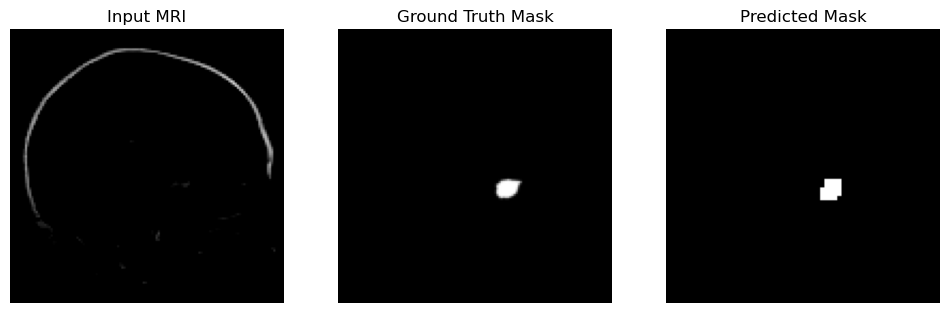

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.79607844].


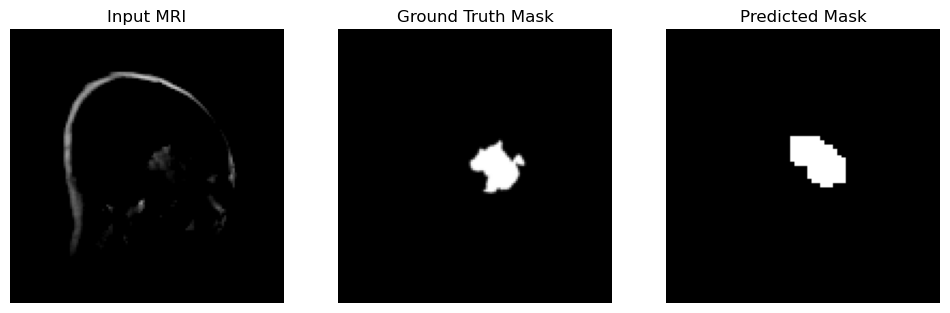

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.37254906].


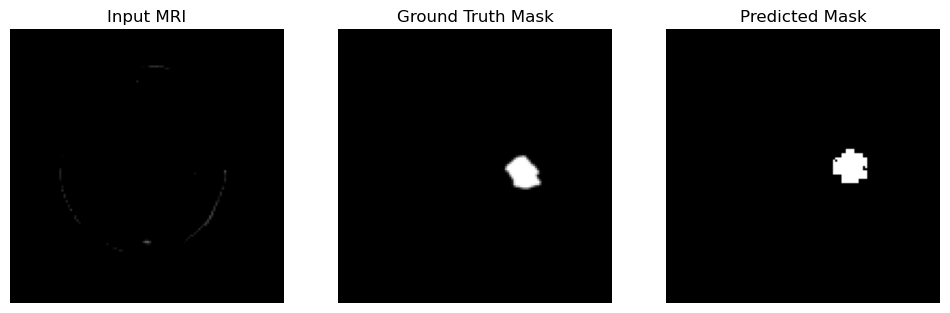

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7254902].


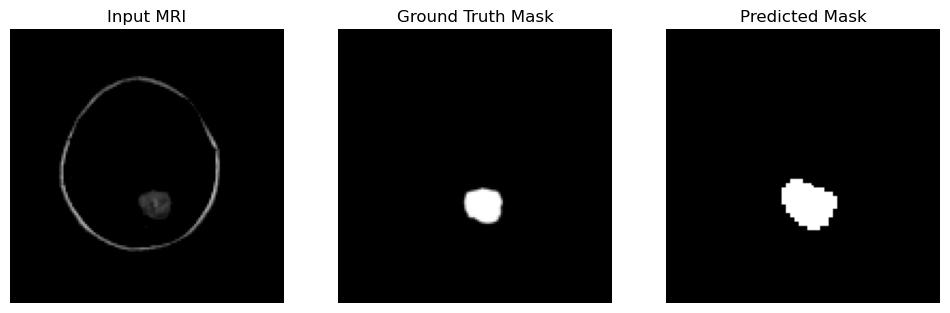

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.4901961].


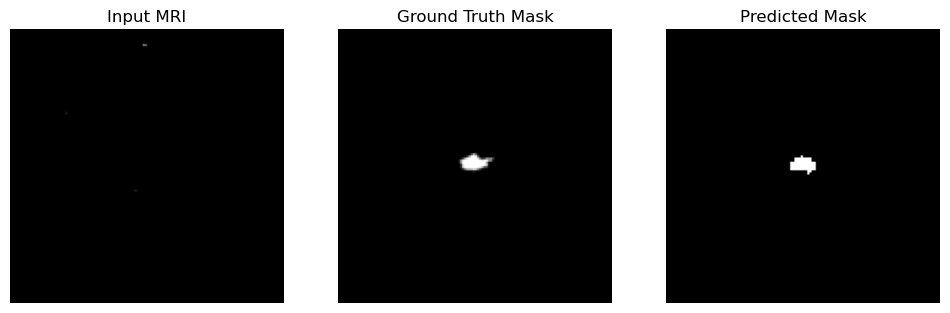

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.39607847].


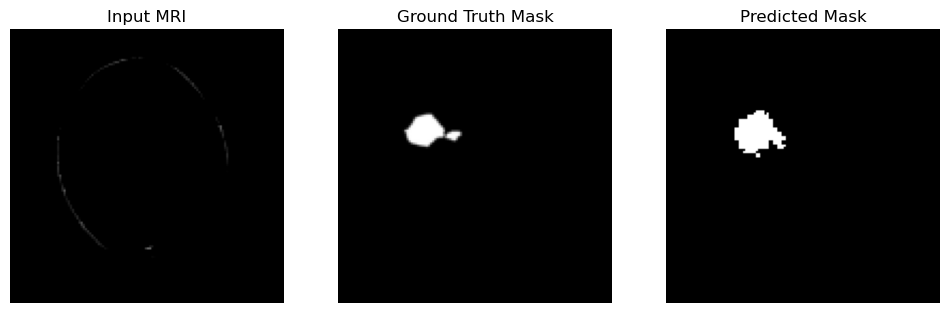

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7411765].


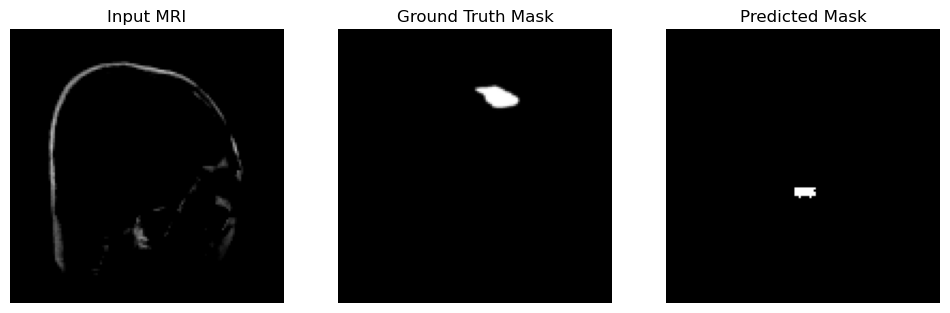

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8666667].


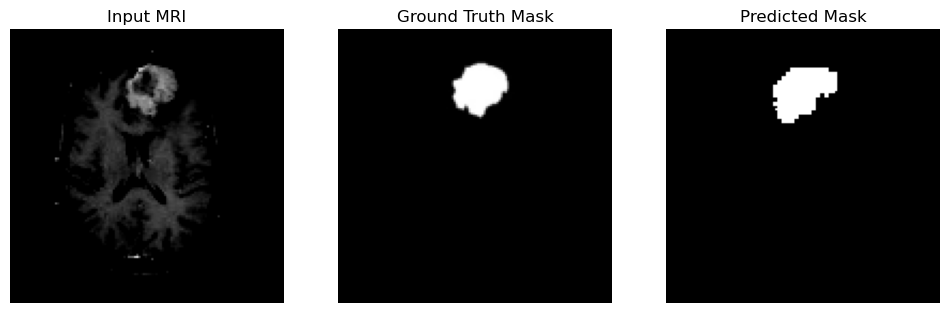

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.56078434].


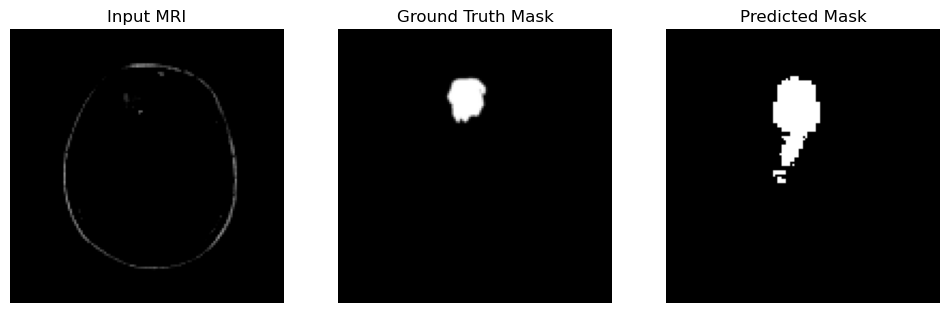

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7490196].


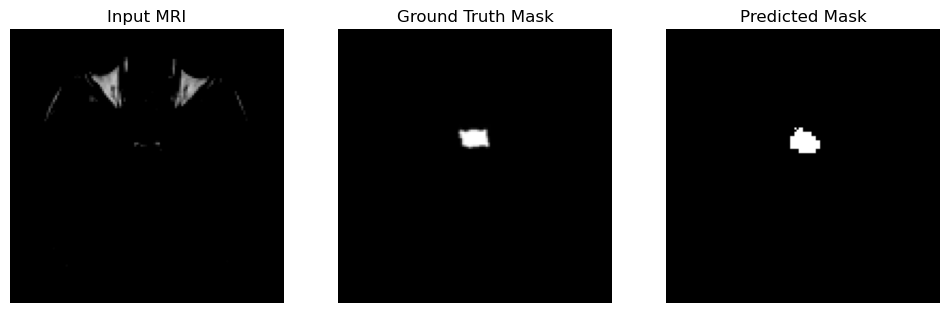

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6].


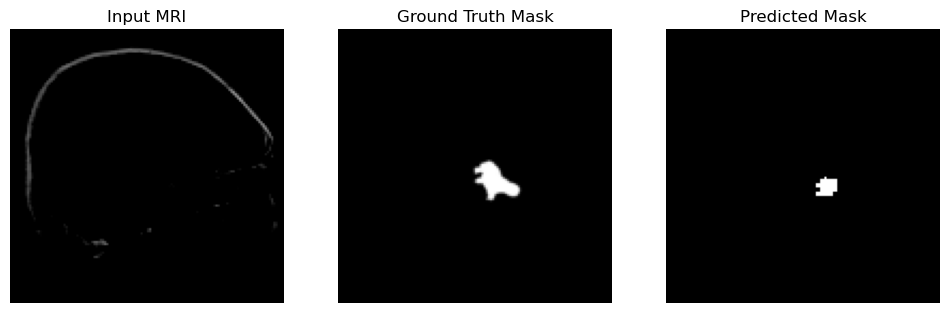

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.64705884].


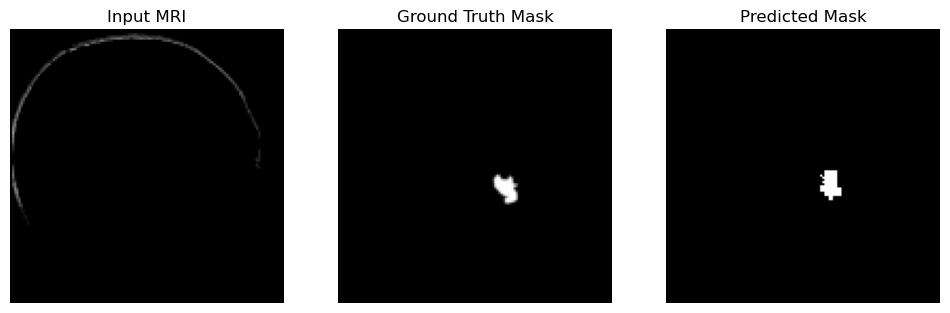

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5372549].


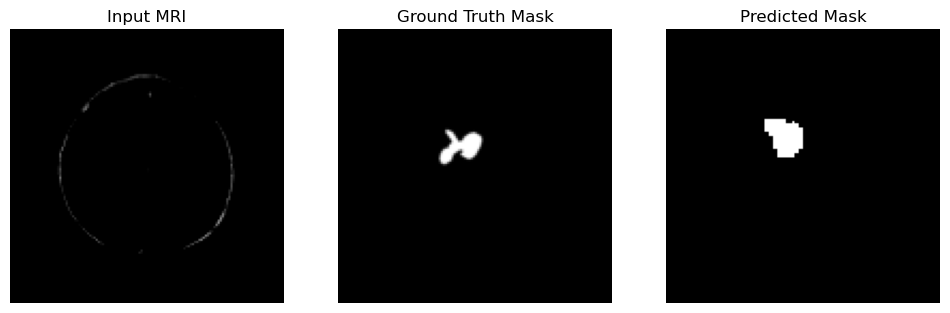

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92156863..0.92156863].


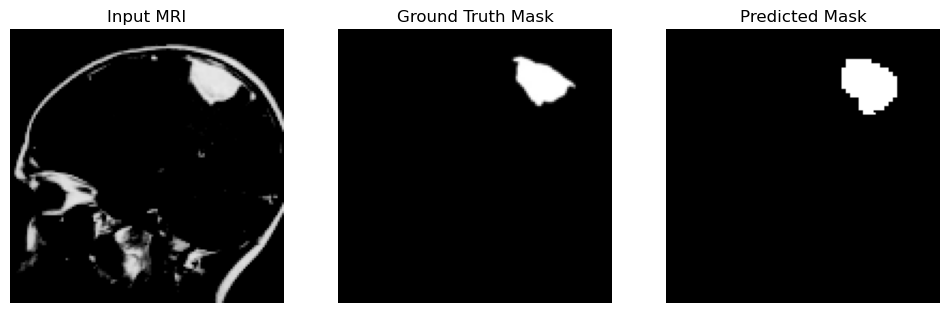

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.45882356].


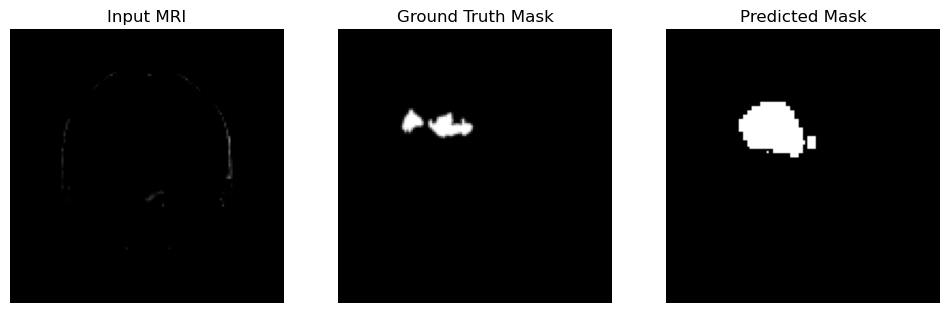

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9372549].


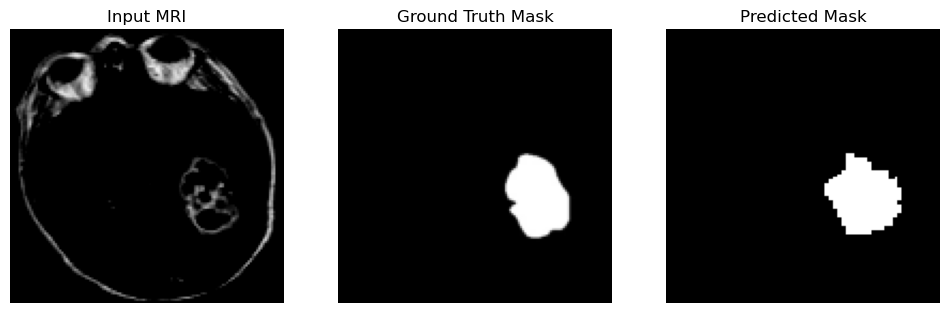

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6313726].


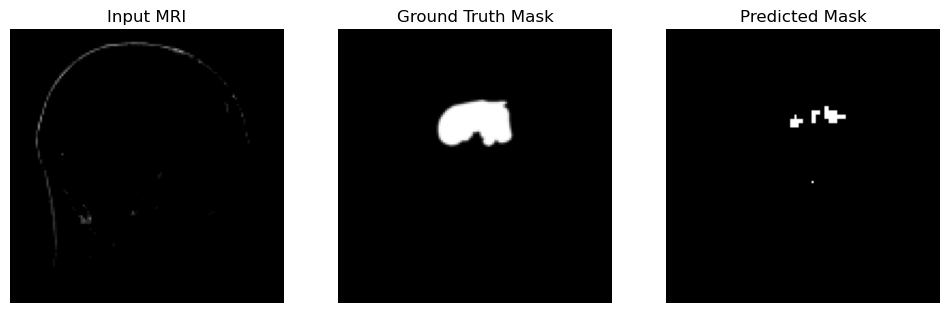

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9764706].


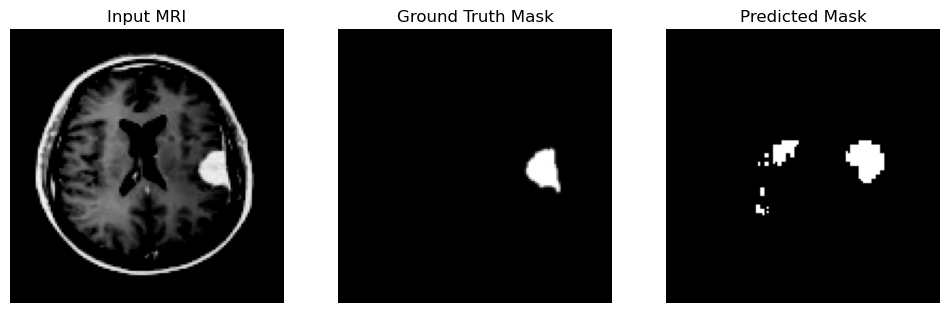

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.36470592].


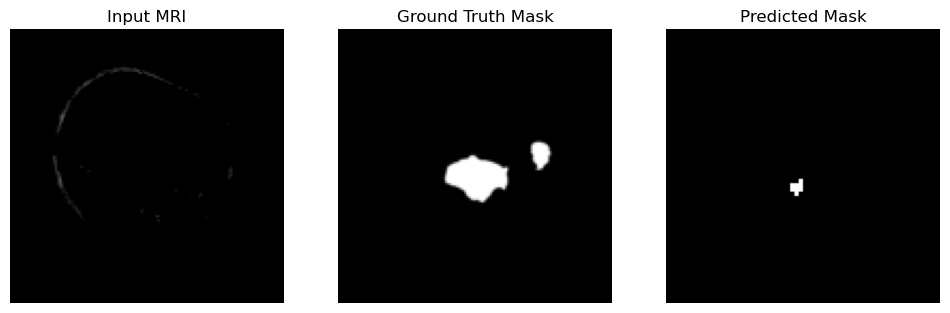

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5686275].


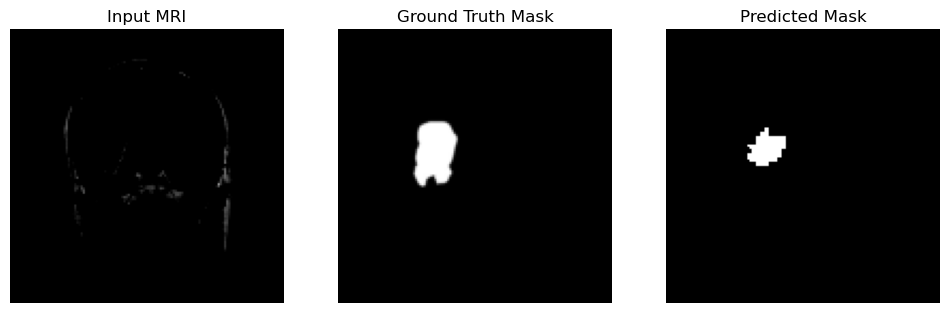

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5058824].


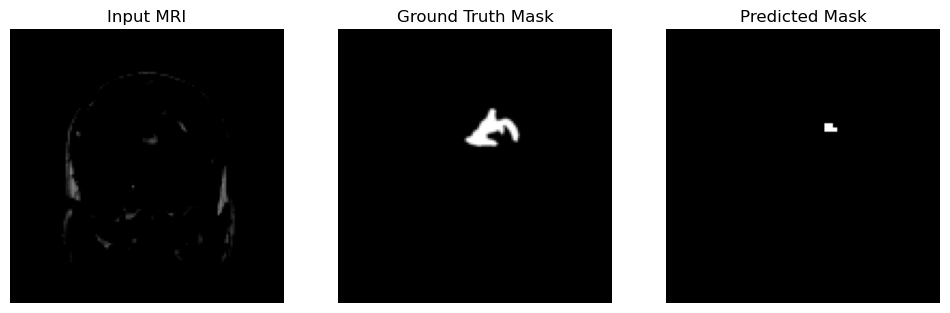

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5921569].


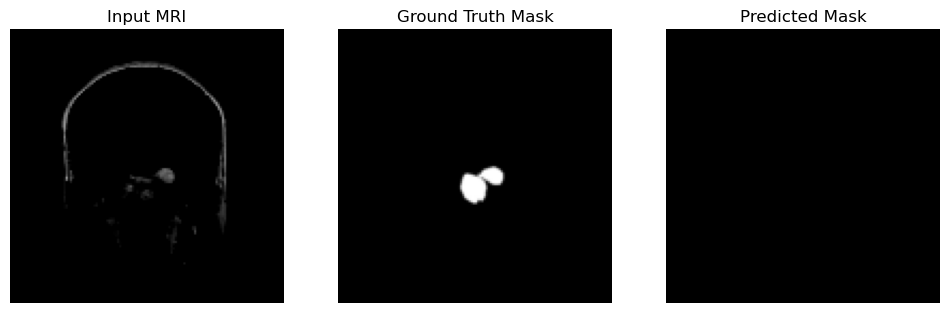

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6].


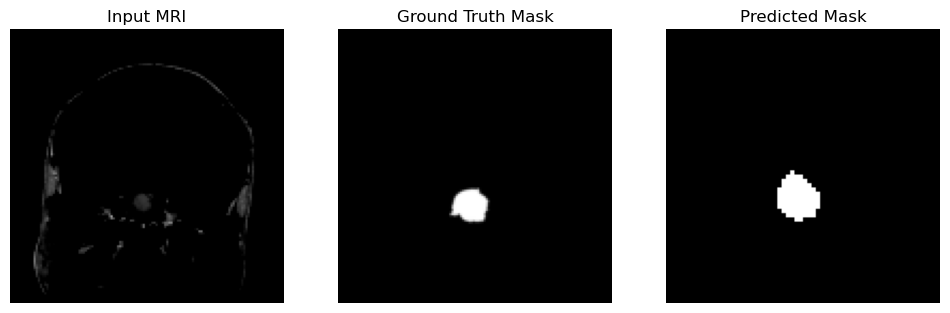

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.56078434].


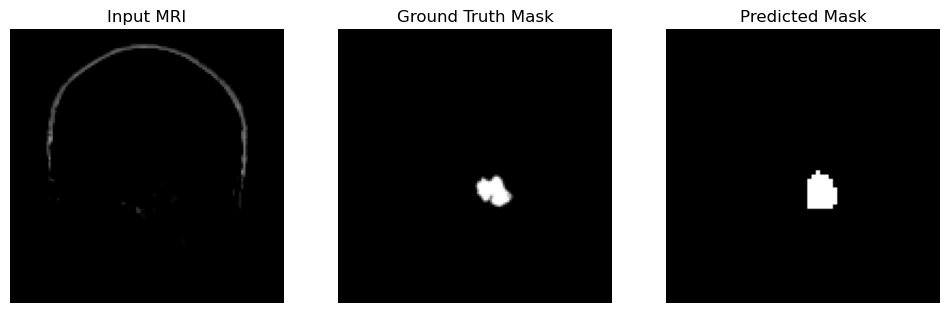

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].


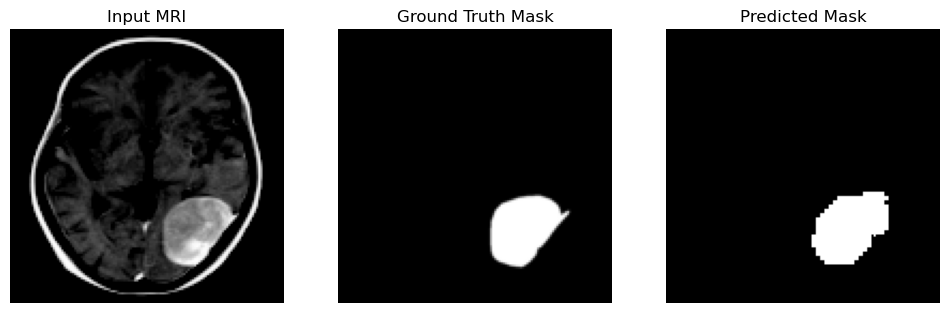

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5372549].


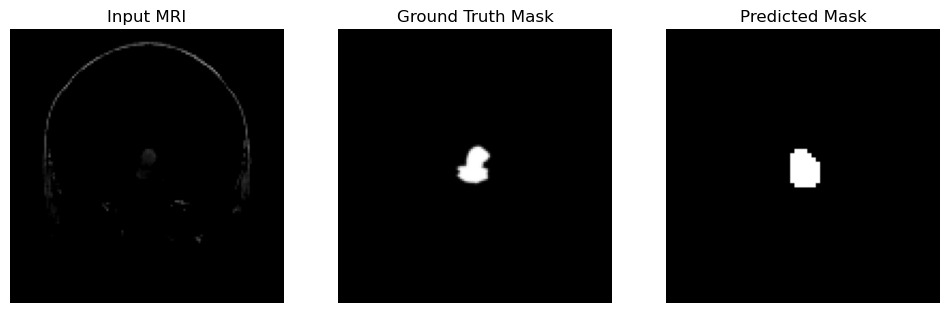

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6862745].


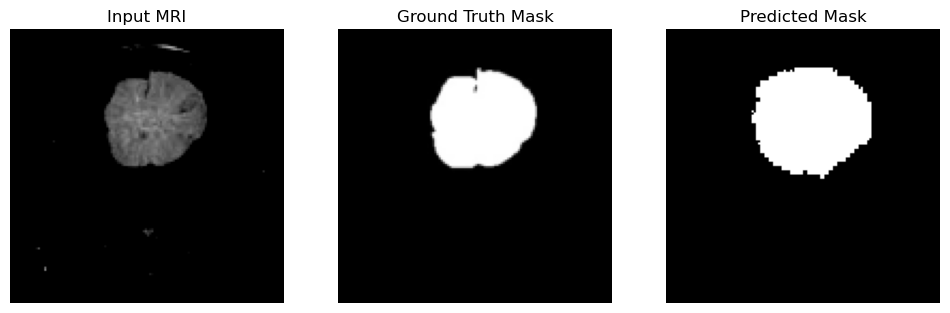

In [31]:
import torch
import matplotlib.pyplot as plt

uNetModel.eval()
with torch.no_grad():
    i = 0
    for batch in test_dataloader:
        imgs, masks = batch        # imgs → MRI, masks → ground truth
        imgs = imgs.to(device)
        masks = masks.to(device)
        
        # model prediction
        outputs = uNetModel(imgs)
        outputs = torch.sigmoid(outputs)
        preds = (outputs > 0.5).float()

        # move all to CPU for visualization
        img = imgs[0].permute(1, 2, 0).cpu()        # [H, W, 3]
        mask_true = masks[0, 0].cpu()               # [H, W]
        mask_pred = preds[0, 0].cpu()               # [H, W]

        # plot input, ground truth, and prediction
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap='gray')
        plt.title('Input MRI')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(mask_true, cmap='gray')
        plt.title('Ground Truth Mask')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(mask_pred, cmap='gray')
        plt.title('Predicted Mask')
        plt.axis('off')

        plt.show()
        i = i + 1

        
